# Evaluacija rezultata modela u stvarnom okruženju

In [1]:
pip install pandas matplotlib seaborn networkx scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\Marta\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from urllib.parse import urlparse
import joblib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
FEATURE_ORDER=[
    'method', 
    'resourceType', 
    'initiatorType', 
    'domainEntropy', 
    'urlEntropy', 
    'isThirdParty', 
    'hasUUID', 
    'urlLength', 
    'status', 
    'mimeType', 
    'latency', 
    'hassizeBytes', 
    'directDomConnections',
    'isAttachedToDom', 
    'suspiciousResHeaders',
    'suspiciousReqHeaders',
    'chainLength', 
    'uniqueDomainsInChain', 
    'consecutiveSameDomainTrack', 
    'queryParamsCount',
    'url',
    'mainPageUrl',
    'predictedLabel'
]

In [3]:
df = pd.read_csv('collected_data.csv', names=FEATURE_ORDER)
df.head(3)

,method,resourceType,initiatorType,domainEntropy,urlEntropy,isThirdParty,hasUUID,urlLength,status,mimeType,...,isAttachedToDom,suspiciousResHeaders,suspiciousReqHeaders,chainLength,uniqueDomainsInChain,consecutiveSameDomainTrack,queryParamsCount,url,mainPageUrl,predictedLabel
0,0,font,3,0.024488,-0.088238,1,0,-0.709945,3,2,...,0,0,0,2,2,0,0.693147,https://s.ltrbxd.com/fonts/Graphik-Regular-Web...,https://letterboxd.com,1
1,0,font,3,0.024488,-0.267883,1,0,-0.683066,3,2,...,0,0,0,2,2,0,0.693147,https://s.ltrbxd.com/fonts/Graphik-Semibold-We...,https://letterboxd.com,0
2,0,font,3,0.024488,-0.498273,1,0,-0.580393,3,2,...,0,0,0,2,2,0,0.693147,https://s.ltrbxd.com/fonts/TiemposTextWeb-Semi...,https://letterboxd.com,0


In [4]:
df.shape

(21572, 23)

In [6]:
df.dropna(inplace=True)
df.shape

(21562, 23)

In [ ]:
## Labeliranje podatak

In [7]:
filter_lists = [
    ("EasyList cookies", "https://secure.fanboy.co.nz/fanboy-cookiemonster.txt"),
    ("EasyPrivacy", "https://easylist-downloads.adblockplus.org/easyprivacy_nointernational.txt"),
    ("Fanboy's annoyance list", "https://easylist.to/easylist/fanboy-annoyance.txt"),
    ("ADVOID Full List", "https://raw.githubusercontent.com/the-advoid/ad-void/refs/heads/main/AdVoid.Full.txt"),
    ("DandelionSprout", "https://raw.githubusercontent.com/DandelionSprout/adfilt/master/LegitimateURLShortener.txt"),
    ("Pete Lowe's Blocklist", "https://pgl.yoyo.org/adservers/serverlist.php?hostformat=adblockplus&showintro=1&mimetype=plaintext"),
    ("AdGuard Tracking protection List", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_3_Spyware/filter.txt"),
    ("AdGuard URL tracking list", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_17_TrackParam/filter.txt"),
    ("AdGuard Annoyance Cookies", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_18_Annoyances_Cookies/filter.txt"),
    ("Adguard Popups", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_19_Annoyances_Popups/filter.txt"),
    ("Adguard base filter + EasyList", "https://filters.adtidy.org/extension/ublock/filters/2.txt")
]

In [8]:
def parseFilterListRules(text):
    rules = text.split('\n')
    ruleCleanupRegex = r"^([^$#\n!]+)"

    substringMatch = set()  # For domain rules and strings
    exceptions = set()      # For @@ rules
    regexMatch = set()      # For /regex/ rules


    for rule in rules:
        strip = rule.strip()
        if not strip or any(strip.startswith(x) for x in ('!', '#', '[')): continue
        if '##' in strip or '#@#' in strip: continue

        if len(strip) <= 3: continue

        # 1. Handle Exceptions (Whitelist)
        if strip.startswith('@@'):
            exceptions.add(strip)
            continue


        # 2. Handle Regex Rules
        elif (strip.startswith('/') and strip.endswith('/') and len(strip) > 1) or "\\" in strip:
            regexMatch.add(strip)
            continue

        else:
          substringMatch.add(strip)
          continue


    return exceptions, regexMatch, substringMatch

In [9]:
exceptions = set()
regexMatch = set()
substringMatch = set()

for name, url in filter_lists:
    try:
        response = requests.get(url)
        response.raise_for_status() 
        print(f"Fetched data from {name}.txt")
        # Parse the rules
        new_exceptions, new_regex, new_substrings = parseFilterListRules(response.text)

        exceptions.update(new_exceptions)
        regexMatch.update(new_regex)
        substringMatch.update(new_substrings)

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from {url}: {e}")

Fetched data from EasyList cookies.txt
Fetched data from EasyPrivacy.txt
Fetched data from Fanboy's annoyance list.txt
Fetched data from ADVOID Full List.txt
Fetched data from DandelionSprout.txt
Fetched data from Pete Lowe's Blocklist.txt
Fetched data from AdGuard Tracking protection List.txt
Fetched data from AdGuard URL tracking list.txt
Fetched data from AdGuard Annoyance Cookies.txt
Fetched data from Adguard Popups.txt
Fetched data from Adguard base filter + EasyList.txt


In [10]:
copy = substringMatch.copy()
for i in exceptions:
  if i in copy:
    substringMatch.remove(i)

In [11]:
pip install adblock

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\Marta\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [12]:
from adblock import Engine, FilterSet
fs = FilterSet()

fs.add_filters(list(exceptions))
fs.add_filters(list(substringMatch))
fs.add_filters(list(regexMatch))

engine = Engine(fs, optimize=True)

In [13]:
df.dropna(inplace=True)
df.shape

(21562, 23)

In [14]:
df["realLabel"] = False
for i, row in df.iterrows():
  result = engine.check_network_urls(
    url=row["url"],
    source_url=row["mainPageUrl"],
    request_type=row["resourceType"]
    )
  df.at[i, "realLabel"] = result.matched

In [15]:
df.to_csv('labeled_data.csv', index=False)

In [ ]:
# Evaluacija podataka

In [16]:
print(classification_report(df["realLabel"], df["predictedLabel"], digits=3))

              precision    recall  f1-score   support

       False      0.905     0.652     0.758     14908
        True      0.521     0.847     0.645      6654

    accuracy                          0.712     21562
   macro avg      0.713     0.750     0.702     21562
weighted avg      0.787     0.712     0.723     21562



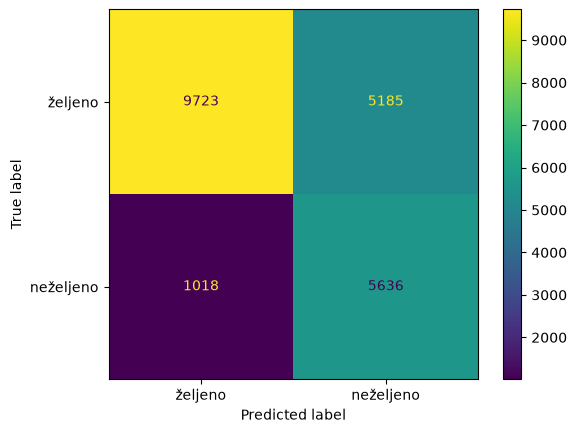

In [17]:
cm = confusion_matrix(df["realLabel"], df["predictedLabel"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['željeno', 'neželjeno'])
disp.plot()
plt.show()

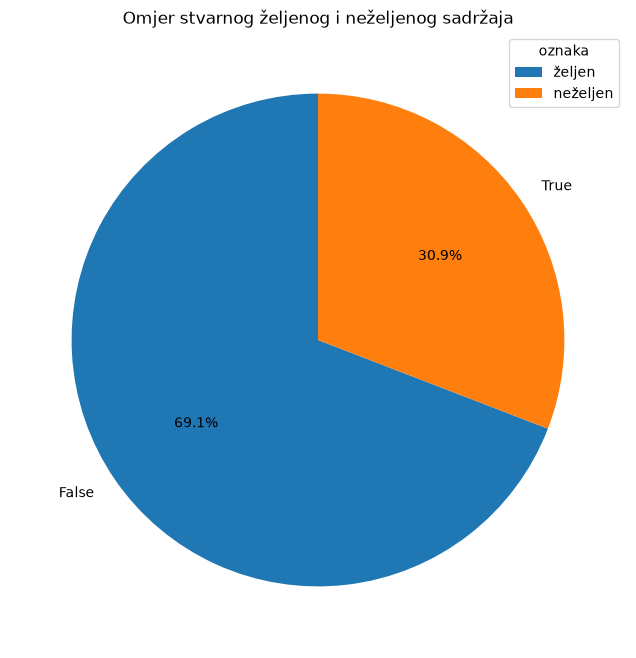

In [18]:
label_counts = df['realLabel'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Omjer stvarnog željenog i neželjenog sadržaja')

legend_labels = ['neželjen' if label == 1 else 'željen' for label in label_counts.index]
plt.legend(legend_labels, title="oznaka")

plt.show()

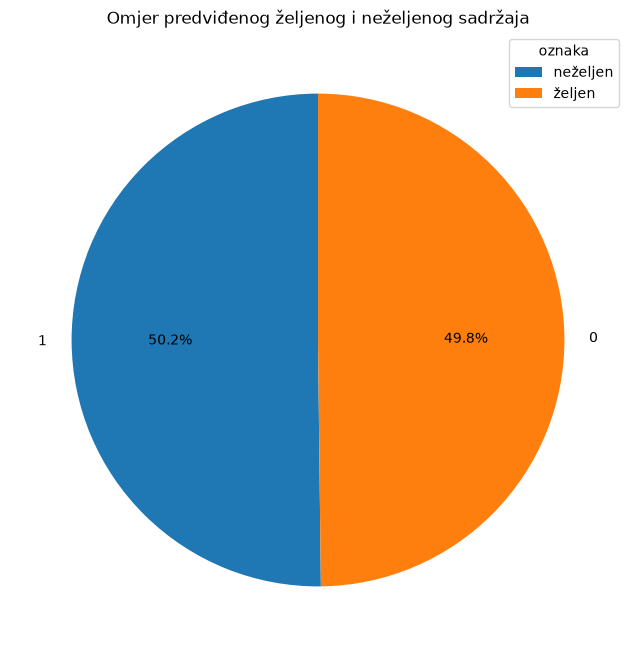

In [19]:
label_counts = df['predictedLabel'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Omjer predviđenog željenog i neželjenog sadržaja')

legend_labels = ['neželjen' if label == 1 else 'željen' for label in label_counts.index]
plt.legend(legend_labels, title="oznaka")

plt.show()

In [20]:
df["mainPageUrl"] = df["mainPageUrl"].apply(lambda x: urlparse(x).netloc if isinstance(x, str) else x)
df["mainPageUrl"].unique()

<StringArray>
[                                                  'letterboxd.com',
                                               'cdn.intergient.com',
                                      'ep2.adtrafficquality.google',
                                              'godofwar.fandom.com',
                                                   'www.fandom.com',
                                             'platform.twitter.com',
                                                  'auth.fandom.com',
                                            'imasdk.googleapis.com',
                                                 'en.wikipedia.org',
                                                    'www.figma.com',
                                                 'player.vimeo.com',
                                                'www.investing.com',
                                                  'api.recurly.com',
                                                    'js.stripe.com',
 '7d643024e89a9449b7

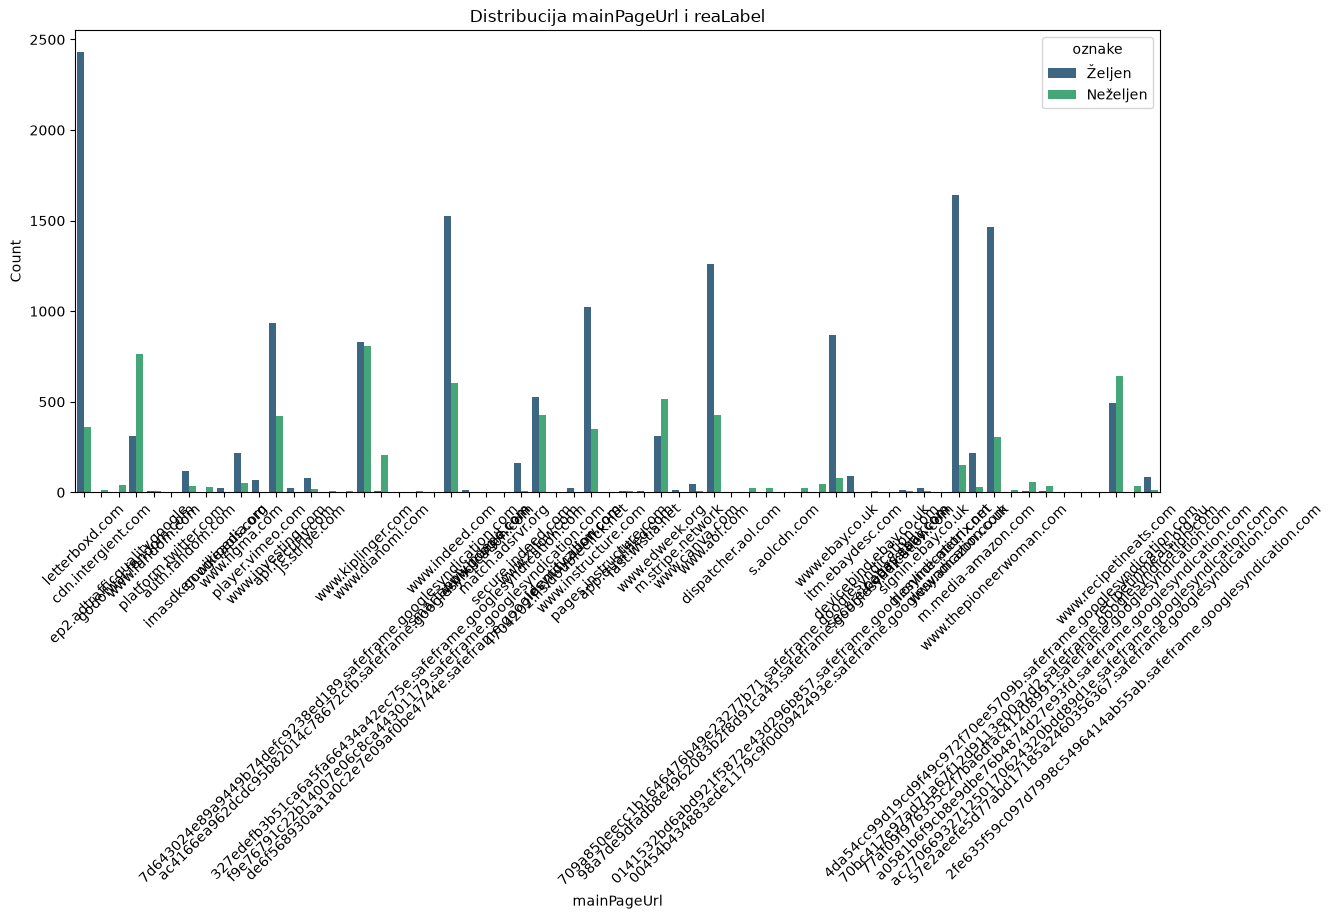

In [21]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x=df["mainPageUrl"], hue=df["realLabel"], palette='viridis')
plt.title(f'Distribucija mainPageUrl i reaLabel')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='oznake', labels=['Željen', 'Neželjen'])
plt.show()

In [92]:
new_data = df["mainPageUrl"].value_counts().reset_index()
new_data.columns = ["mainPage", "count"]
new_data.head()

,mainPage,count
0,letterboxd.com,320
1,www.zillow.com,302
2,www.amazon.co.uk,296
3,www.aol.com,286
4,www.instructure.com,254


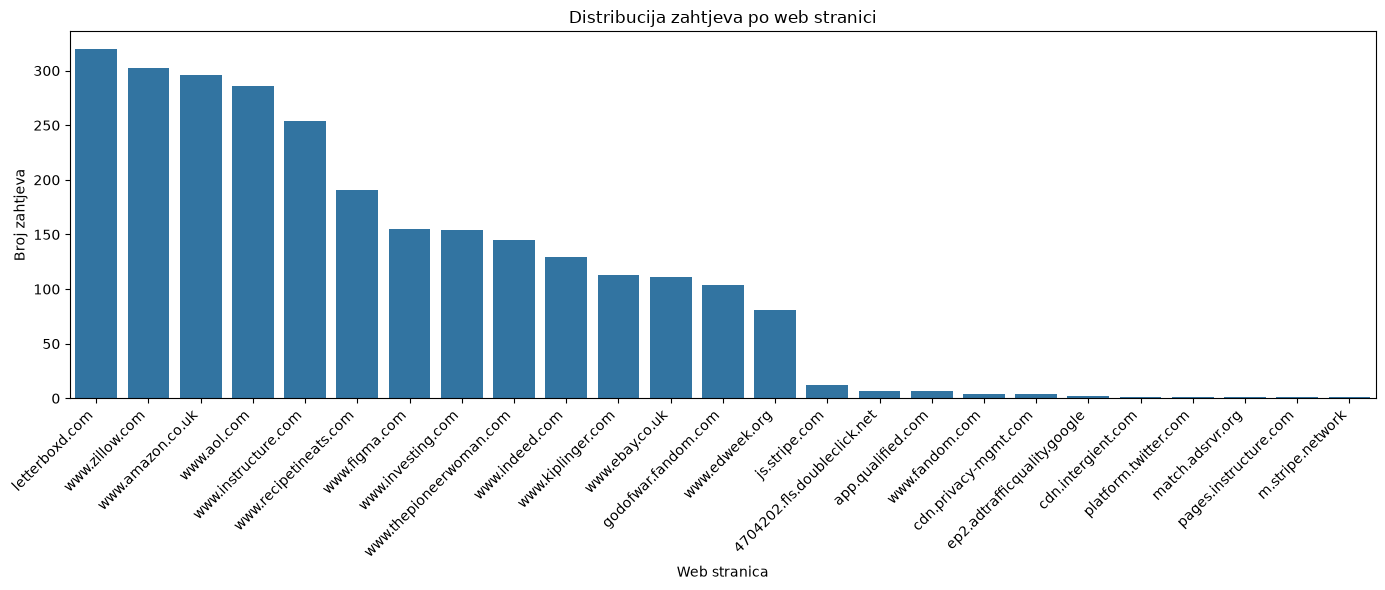

In [93]:
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df,
    x="mainPageUrl",
    order=df["mainPageUrl"].value_counts().index,
)
plt.title('Distribucija zahtjeva po web stranici')
plt.ylabel('Broj zahtjeva')
plt.xlabel('Web stranica')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


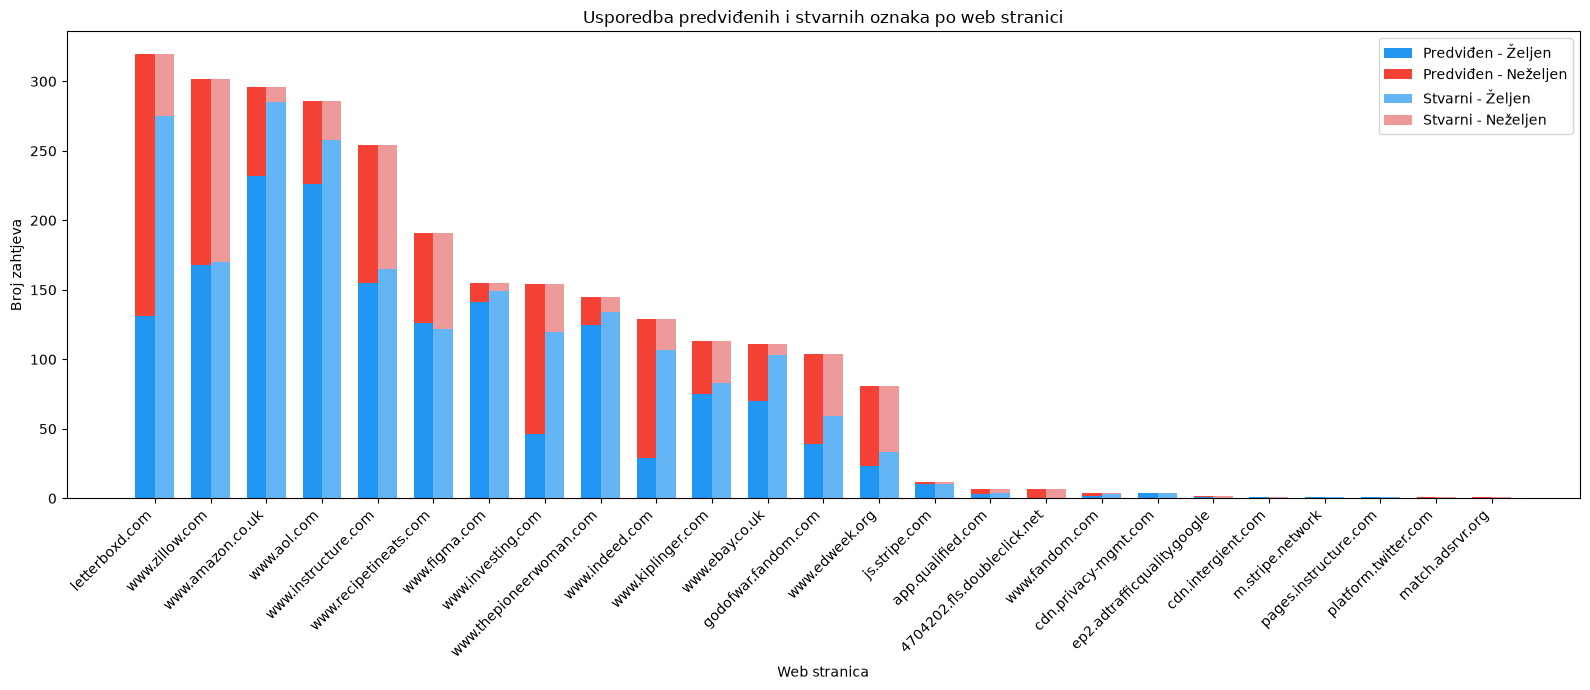

In [98]:
# Aggregate data per mainPage
summary = df.groupby("mainPageUrl").agg(
    pred_wanted=("predictedLabel", lambda x: (x == 0).sum()),
    pred_unwanted=("predictedLabel", lambda x: (x == 1).sum()),
    real_wanted=("realLabel", lambda x: (x == 0).sum()),
    real_unwanted=("realLabel", lambda x: (x == 1).sum())
).reset_index()

# Add total count and sort by it
summary["total"] = summary["pred_wanted"] + summary["pred_unwanted"]
summary = summary.sort_values("total", ascending=False).reset_index(drop=True)

pages = summary["mainPageUrl"]
x = np.arange(len(pages))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

# Predicted bars (left)
ax.bar(x - width/2, summary["pred_wanted"],   width, label="Predviđen - Željen",   color="#2196F3")
ax.bar(x - width/2, summary["pred_unwanted"], width, label="Predviđen - Neželjen", color="#F44336", bottom=summary["pred_wanted"])

# Real bars (right)
ax.bar(x + width/2, summary["real_wanted"],   width, label="Stvarni - Željen",      color="#64B5F6")
ax.bar(x + width/2, summary["real_unwanted"], width, label="Stvarni - Neželjen",    color="#EF9A9A", bottom=summary["real_wanted"])

ax.set_xticks(x)
ax.set_xticklabels(pages, rotation=45, ha='right')
ax.set_title("Usporedba predviđenih i stvarnih oznaka po web stranici")
ax.set_ylabel("Broj zahtjeva")
ax.set_xlabel("Web stranica")
ax.legend()
plt.tight_layout()
plt.show()